In [1]:
# Basic imports and setup
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.interpolate import interp1d
from analyze_modules import load_parameter_sweep
from analyze_modules.plot_utils import _get_scalar_data

# get viridis colormap
cmap = plt.get_cmap('viridis')
cmap.set_bad(color='black')
plt.rcParams['figure.dpi'] = 200

In [2]:
# habitability params
T_freeze = 273.15 # K
T_boil = np.array([100, 180, 310]) # deg C for P = [1, 10, 100] bar
T_boil = T_boil + T_freeze # K
P_boil = np.array([1, 10, 100]) # bar

names = np.array(['H2', 'He', 'N2', 'CH4', 'O2', 'CO2', 'H2O', 'NH3', 'CO'])
masses = np.array([2.016, 4.0026, 28.0134, 16.0425, 31.9988, 44.0095, 18.0153, 17.031, 28.010]) # amu
# from https://en.wikipedia.org/wiki/Triple_point
triple_Ts = np.array([13.8033, 2.1768, 63.18, 90.68, 54.36, 216.55, 273.16, 195.4, 68.1]) # K
triple_Ps = np.array([7.04e3, 5.048e3, 12.6e3, 11.7e3, 0.144e3, 517e3, 0.611657e3, 6.06e3, 15.37e3]) # Pa
triple_Ps *= 1e1 # to dyn/cm^2
# from https://en.wikipedia.org/wiki/Critical_point_(thermodynamics)
critical_Ts = np.array([33.20, 5.19, 126.2, 190.8, 154.33, 304.19, 647.1, 405.5, 133.16]) # K
critical_Ps = np.array([1.300e6, 0.227e6, 3.39e6, 4.64e6, 5.043e6, 7.38e6, 22.06e6, 11.28e6, 3.498e6]) # Pa
critical_Ps *= 1e1 # to dyn/cm^2

mol_dict = {name: {'mass': mass, 'triple': [Tt, Pt], 'critical': [Tc, Pc]} for name, mass, Tt, Pt, Tc, Pc in zip(names, masses, triple_Ts, triple_Ps, critical_Ts, critical_Ps)}

In [19]:
# Parameters
P0s = np.array(['critical'])
Tints = np.array([100, 150, 200, 250, 300, 350]) # K
# CplusOs = np.array([1e-3, 1e-2, 1e-1])
# CtoOs = np.array([0.1, 0.59, 1.0])
#aHs = np.array([1e-6, 1e-2, 1e-1, 1e0, 3e0])
#aCs = np.array([1e-6, 1e-2, 1e-1, 2.5e-1, 5e-1])
#aOs = np.array([1e-6, 1e-2, 1e-1, 5e-1, 1e0])
#aNs = np.array([1e0])
#planets = np.array(['Earth'])
#adds = ['', '_aN=1e-4', '_aN=1e-2']
cia_names = np.array(["CH4-CH4_2011", "CO2-CH4_2024_main", "CO2-CH4_2020", "CO2-CO2_2024", "CO2-CO2_2011", "CO2-H2_2024", "CO2-H2_2018", "H2-CH4_eq_2011", "N2-CH4_2024", "N2-CH4_2011", "N2-H2_2024", "N2-H2O_2018", "N2-N2_2021", "N2-N2_lowT_2018", "H2-H2_2018+02", "H2-H2_2018+11"])
#cia_names = np.array(["CO2-CH4_2024_main", "CO2-CH4_2024_alt", "CO2-CH4_2020", "CO2-CH4_2017"])
folders = np.array(['../output/CIA_comparison_HELIOS_varFloor/'])

#cia_names = np.array(["comparison/CIA_CO2-CH4_2024_main", "comparison_varConvGrad/CIA_CO2-CH4_2024_main", "comparison/CIA_CO2-CH4_2024_alt", "comparison_varConvGrad/CIA_CO2-CH4_2024_alt", "comparison/CIA_CO2-CH4_2020", "comparison_varConvGrad/CIA_CO2-CH4_2020", "comparison/CIA_CO2-CH4_2017", "comparison_varConvGrad/CIA_CO2-CH4_2017"])
#cia_names = np.array(["comparison/CIA_CO2-CH4_2024_main", "comparison_varConvGrad/CIA_CO2-CH4_2024_main", "comparison/CIA_CO2-CH4_2017", "comparison_varConvGrad/CIA_CO2-CH4_2017"])
#cia_names = np.array(["comparison/CIA_N2-H2_2024", "comparison_varConvGrad/CIA_N2-H2_2024"])
#folders = np.array(['../output/'])

def build_name(params):
    
    planet = params['planet']
    temp = params['Tint']
    psurf = params['P0']
    a_h = params['aH']
    a_c = params['aC']
    a_o = params['aO']
    a_n = params['aN']

    psurf_bar = int(psurf/1e6)

    return f"{planet}_Tint={temp}K_Psurf={psurf_bar}bar_aH={a_h}_aC={a_c}_aO={a_o}_aN={a_n}"

def build_name_cia(params):

    cia_name = params['cia_name']
    temp = params['Tint']
    psurf = params['P0']

    psurf_bar = int(psurf/1e6)
    
    return f"CIA_{cia_name}_Tint={temp}K_Psurf={psurf_bar}bar"


In [20]:
# Load the data by performing sweeps inside a loop

loop_over = cia_names # e.g. planets or N abundances or folders
# ! adjust fixed parameters accordingly

tsurfs = np.zeros((len(loop_over), len(P0s), len(Tints)))

#i_cia_name = 15
# i_CplusO = 2
# i_CtoO = 1
# i_aH = 3
# i_aC = 2
# i_aO = 1
# i_aN = 0

for i_loop, loop_name in enumerate(loop_over):
    for i_P0, p0_val in enumerate(P0s):

        if p0_val == 'critical':
            p0_val = np.min([mol_dict[mol]['critical'][1] for mol in cia_names[i_loop].split('/')[-1].split('_')[0].split('-')])
        else:
            p0_val = float(p0_val)
        
        fixed_params = {
            #'planet': planets[0],
            #'add': adds[0],
            'P0': p0_val,
            #'CplusO': CplusOs[i_CplusO],
            #'CtoO': CtoOs[i_CtoO]
            #'aH': aHs[i_aH],
            #'aC': loop_over[i_loop],
            #'aO': aOs[i_aO],
            #'aN': aNs[i_aN],
            'cia_name': cia_names[i_loop]
        }
        
        # Perform a sweep over internal temperature
        run_list = load_parameter_sweep(
            folders[0],
            fixed_params=fixed_params,
            varying_param_name='Tint',
            varying_param_values=Tints,
            build_name=build_name_cia,
            load_mode='all'
        )

        #print([run.iterations_read for run in run_list])
        
        # Extract the surface temperature from each run
        # This uses the helper function from plot_utils internally for consistency
        surf_temps = [run.temperatures_K[-1,0] for run in run_list]
        surf_temps_control = [run.temperatures_K[-2,0] if run.temperatures_K.shape[0] > 1 else np.nan for run in run_list]
        surf_temps = [surf_temps[i] if np.isclose(surf_temps_control[i], surf_temps[i], atol=1e0) else np.nan for i in range(len(surf_temps))]
        tsurfs[i_loop, i_P0, :] = surf_temps

        if np.any(np.isnan(surf_temps)):
            print("NaN encountered for", loop_name, "at P0 =", int(p0_val/1e6), "bar", Tints[np.isnan(surf_temps)])



print(np.sum(np.isnan(tsurfs)), 'of', np.prod(tsurfs.shape))

NaN encountered for CH4-CH4_2011 at P0 = 46 bar [200]
NaN encountered for CO2-CH4_2024_main at P0 = 46 bar [100]
No valid data found for run CIA_CO2-CH4_2020_Tint=150K_Psurf=46bar
No valid data found for run CIA_CO2-CH4_2020_Tint=250K_Psurf=46bar
NaN encountered for CO2-CH4_2020 at P0 = 46 bar [100 150 250]
NaN encountered for CO2-CO2_2024 at P0 = 73 bar [200]
NaN encountered for CO2-CO2_2011 at P0 = 73 bar [200 250]
NaN encountered for N2-H2O_2018 at P0 = 33 bar [250 300]
No valid data found for run CIA_N2-N2_2021_Tint=300K_Psurf=33bar
No valid data found for run CIA_N2-N2_2021_Tint=350K_Psurf=33bar
NaN encountered for N2-N2_2021 at P0 = 33 bar [300 350]
No valid data found for run CIA_N2-N2_lowT_2018_Tint=300K_Psurf=33bar
No valid data found for run CIA_N2-N2_lowT_2018_Tint=350K_Psurf=33bar
NaN encountered for N2-N2_lowT_2018 at P0 = 33 bar [100 300 350]
15 of 96


In [21]:
def set_white(ax):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    ax.tick_params(axis='x', colors='white', which='both')  # Set color for both major and minor ticks
    ax.tick_params(axis='y', colors='white', which='both')  # Set color for both major and minor ticks

    try: # if colorbar is present
        ax.images[0].colorbar.ax.yaxis.label.set_color('white')
        ax.images[0].colorbar.ax.tick_params(axis='y', colors='white', which='both')
        ax.images[0].colorbar.outline.set_color('white')
    except:
        pass

def increase_size(ax, linewidth=3, fontsize=14, legendcols=1, legendloc='best'):
    for l in ax.lines:
        l.set_linewidth(linewidth)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(linewidth)
    ax.xaxis.set_tick_params(width=linewidth)
    ax.yaxis.set_tick_params(width=linewidth)
    ax.xaxis.label.set_size(fontsize)
    ax.yaxis.label.set_size(fontsize)
    ax.xaxis.set_tick_params(labelsize=fontsize)
    ax.yaxis.set_tick_params(labelsize=fontsize)
    if legendloc != 'no':
        ax.legend(fontsize=fontsize, ncols=legendcols, loc=legendloc)

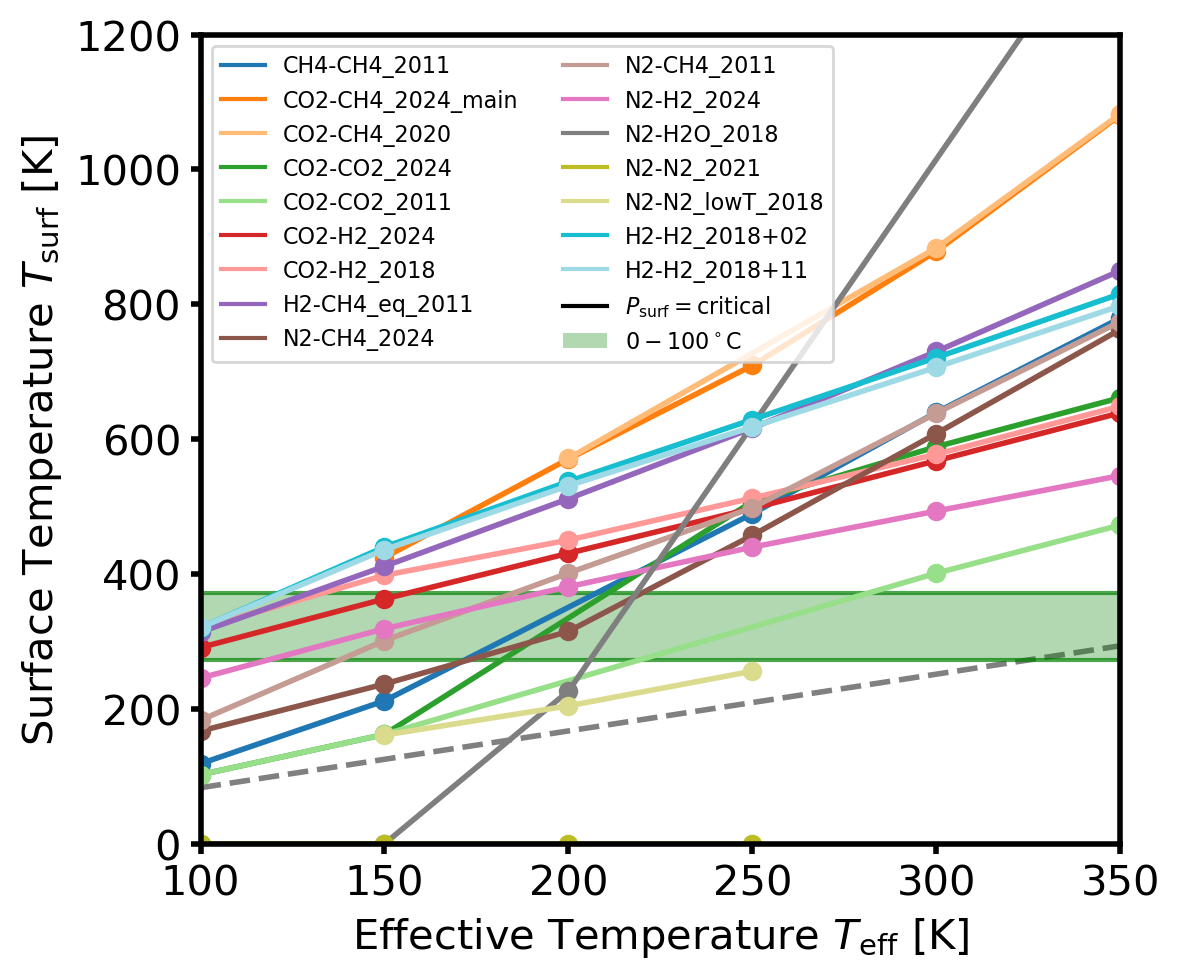

In [22]:
fig, ax = plt.subplots(figsize=(6, 5))
linestyles = ['o-', 'o--', 'o:']
#colors = ['tab:blue', 'tab:orange', 'tab:red', 'tab:green', 'tab:purple']
# colors for CIAs
tab10 = plt.cm.tab10.colors
tab20 = plt.cm.tab20.colors
skip = np.array([0, 4, 6, 7]) # CIA pairs with only one source
#skip = []
colors = [[tab20[i], tab20[i+1]] if i not in skip*2 else [tab20[i]] for i in np.arange(10)*2] # dark and light colors for main/alt sources, where available
colors = [item for sublist in colors for item in sublist]

#print(colors[:3])

#for i, planet_name in enumerate(planets):
for i_loop, loop_name in enumerate(loop_over):
    for i_P0, p0_val in enumerate(P0s):
        #if loop_name.split('_')[0] != "H2-H2":
        #    break
        mask = ~np.isnan(tsurfs[i_loop, i_P0, :])
        mask = np.logical_and(mask, ~(tsurfs[i_loop, i_P0, :] == 500.))
        # print tsurf at certain T_int
        #print(f"T_surfs for {loop_name}, P0={p0_val}:", [f"{tsurf:.2f}" for tsurf in tsurfs[i_loop, i_P0, :]])
        ax.plot(
            Tints[mask], 
            tsurfs[i_loop, i_P0, mask], 
            linestyles[i_P0], 
            color=colors[i_loop],
            label=None #f'{planet_name}, {p0_val/1e6:g} bar'
        )

xmin = 100
plt.hlines(T_freeze, xmin, Tints[-1], color='green', alpha=0.7, zorder=0)
plt.fill([xmin, xmin, Tints[-1], Tints[-1]], [T_boil[0], T_freeze, T_freeze, T_boil[0]], 'green', alpha=0.3, label=r'$0-100^\circ$C', zorder=-5)
for i_P0 in range(len(P0s)):
    #plt.hlines(T_boil[i_P0+2], xmin, Tints[-1], color='green', linestyle=linestyles[i_P0][1:], alpha=0.7, zorder=0)
    plt.hlines(T_boil[0], xmin, Tints[-1], color='green', linestyle=linestyles[i_P0][1:], alpha=0.7, zorder=0)
    break

plt.plot(Tints, Tints/2**(1/4), '--', color='grey', zorder=-10)

ax.set_xlim(xmin, 350)
ax.set_ylim(0, 1200)
ax.set_xlabel(r'Effective Temperature $T_\mathrm{eff}$ [K]')
ax.set_ylabel(r'Surface Temperature $T_\mathrm{surf}$ [K]')

lgd = ax.legend()

#folder_labels = ['HELIOS', 'fast, H2-H2 CIA', 'fast, all CIAs']
handles, labels = ax.get_legend_handles_labels()
for i in range(len(loop_over)):
    handles.append(plt.Line2D([0], [0], color=colors[i]))
    labels.append(loop_over[i])
    #labels.append(folder_labels[i])
    #labels.append(planets[i] + ' gravity')
    #labels.append(r'$X_\mathrm{N}$ = 0.0' if adds[i] == '' else (r'$X_\mathrm{N}$ = ' + f'{adds[i][-4:]}'))
    #labels.append(r'$X_\mathrm{C+O}$ = ' + f'{CplusOs[i]}')
    #labels.append(r'$a_\mathrm{C}$ = ' + f'{loop_over[i]}')
for i in range(len(P0s)):
    handles.append(plt.Line2D([0], [0], linestyle=linestyles[i][1:], color='black'))
    if P0s[i] == 'critical':
        labels.append(r'$P_\mathrm{surf}=$' + P0s[i])
    else:
        labels.append(r'$P_\mathrm{surf}=$' + f'{float(P0s[i])*1e-6:.0f} bar')
handles.append(handles[0])
labels.append(labels[0])
handles = handles[1:]
labels = labels[1:]
#print(len(handles), labels)
lgd = ax.legend(handles, labels, loc='upper left', fontsize=8, ncols=2)

#plt.plot(100, 110, 'o', color=colors[1])

# turn on preferred options
#set_white(ax)
increase_size(ax, linewidth=2, fontsize=15, legendloc='no')
#ax.set_ylabel('')
plt.tight_layout()
#plt.savefig(f"images/JulyPoster/CompareGravity_CplusO={CplusOs[i_CplusO]}_CtoO={CtoOs[i_CtoO]}.svg", format="svg", transparent=True)

plt.show()

In [38]:
# Calculate internal temperature where surface temperature is equal to freezing point

loop_overs = aCs

Tints_freeze = np.zeros((len(loop_overs), len(P0s)))
Tints_boil = np.zeros((len(loop_overs), len(P0s)))

for i_P0 in range(len(P0s)):
    for i, loop_over in enumerate(loop_overs):
        if np.isnan(tsurfs[i,i_P0,:]).all():
            continue
        mask = np.isnan(tsurfs[i,i_P0,:])
        Tsurf = tsurfs[i,i_P0,~mask]
        Tint = Tints[~mask]

        # interpolate Tsurf to find Tint
        f = interp1d(Tsurf, Tint, bounds_error=False, fill_value='extrapolate')
        Tint_freeze = f(T_freeze)
        Tint_boil = f(T_boil[i_P0])

        Tints_freeze[i,i_P0] = Tint_freeze
        Tints_boil[i,i_P0] = Tint_boil

        print(f'{loop_over} P0={P0s[i_P0]*1e-6:.0f} bar: Tint_freeze = {Tint_freeze:.2f} K')
        print(f'{loop_over} P0={P0s[i_P0]*1e-6:.0f} bar: Tint_boil = {Tint_boil:.2f} K')

print(np.average(Tints_freeze[1,:]/Tints_freeze[0,:]))

print((1821 / 6371)**(3/4))


NameError: name 'aCs' is not defined

In [112]:
# connect Tsurf to time evolution

# read in T_eff data from data/T_eff.dat (format: index, time, T_eff, a_moon, e_moon)
T_eff = np.loadtxt('../../FFP-Exomoons/output_Teff.out')
print(T_eff.shape)

n_time = 1000 #int(1000/10 + 1)

T_eff = T_eff.reshape((-1,n_time,5))
print(T_eff.shape)
print(T_eff[2,:,0].astype(int))

FileNotFoundError: ../../FFP-Exomoons/output_Teff.out not found.

Time t = 1992.1375364285097
> inf K: 0 out of 6945


Text(0.5, 1.0, 'T_eff at t=1992 Myr')

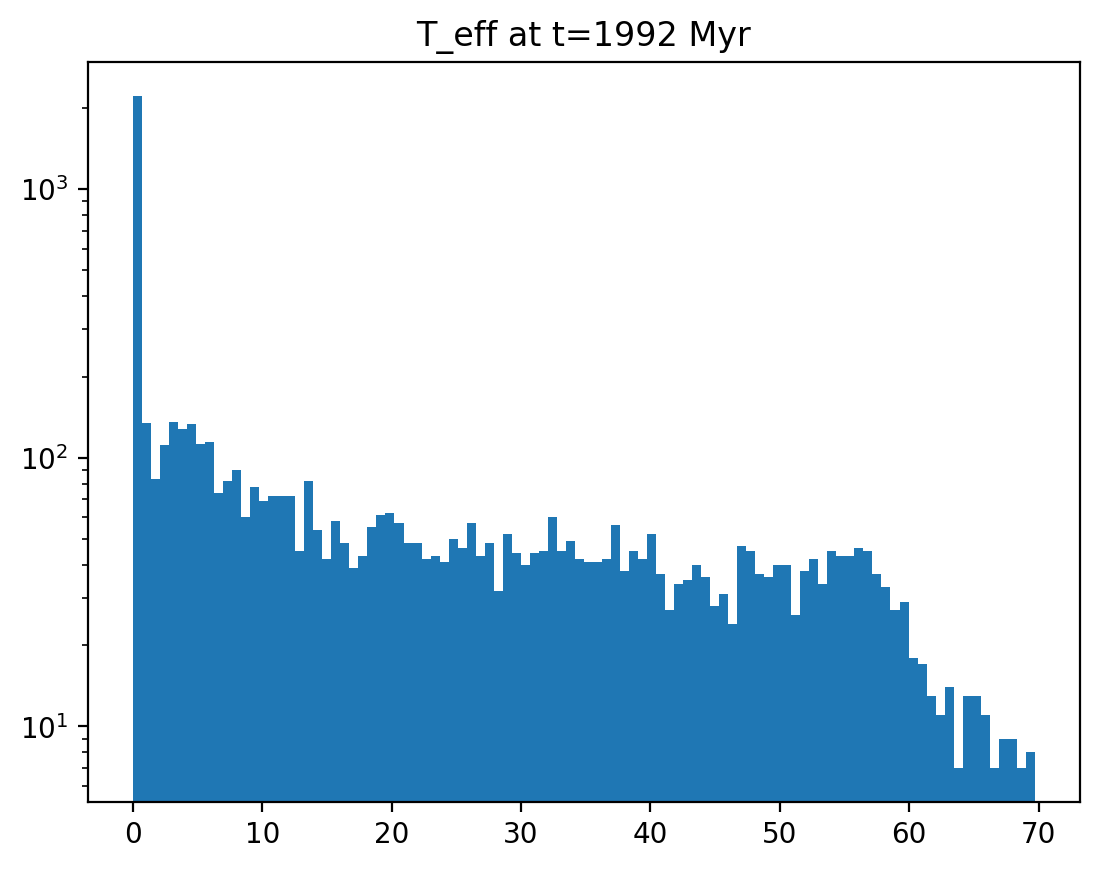

In [10]:
time = 2000 # Myr
i_time = np.argmin(np.abs(T_eff[0,:,1] - time))
print('Time t =', T_eff[0,i_time,1])

plot_T_eff = T_eff[:,i_time,2]

T_max = np.inf
T_eff_mask = plot_T_eff < T_max
print(f'> {T_max} K:', np.sum(~T_eff_mask), 'out of', len(plot_T_eff))
plot_T_eff = plot_T_eff[T_eff_mask]


plt.hist(plot_T_eff, bins=100, log=True)
plt.title(f'T_eff at t={T_eff[0,i_time,1]:.0f} Myr')

In [11]:
# calculate time spent in the habitable zone

t_minmax = np.zeros((len(loop_overs), len(P0s), T_eff.shape[0], 2))
time_habitable = np.zeros((len(loop_overs), len(P0s), T_eff.shape[0], 1))
switches = np.zeros((len(loop_overs), len(P0s), T_eff.shape[0]))

dt = np.zeros(T_eff.shape[1]+1)
dt[1:-1] = (T_eff[0,:-1,1] + T_eff[0,1:,1])/2
dt[0] = T_eff[0,0,1]
dt[-1] = T_eff[0,-1,1]
dt = dt[1:] - dt[:-1]

for i in range(len(loop_overs)):
    for i_p, P in enumerate(P0s):

        habitable = np.zeros(T_eff.shape[:2], dtype=bool)

        for i_t in range(n_time):
            T_eff_i = T_eff[:, i_t, 2]
            T_surf_i = np.interp(T_eff_i, Tints, tsurfs[i, i_p, :])

            habitable[:,i_t] = np.logical_and(T_surf_i >= T_freeze, T_surf_i <= T_boil[i_p])

        switch = np.diff(habitable.astype(int), axis=1)
        switches[i,i_p,:] = np.sum(switch == -1, axis=1)

        for i_moon in range(T_eff.shape[0]):
            time_habitable[i,i_p,i_moon,0] = np.sum(dt[habitable[i_moon,:]])

        # EXTRA TEST STUFF
        # habitable_test = np.zeros(T_eff.shape[0], dtype=bool)
        # for i_t in range(n_time):
        #     T_eff_i = T_eff[:, i_t, 2]
        #     T_surf_i = np.interp(T_eff_i, Tints, tsurfs[i, i_p, :])
        #     mask = np.logical_and(T_surf_i >= T_freeze, T_surf_i <= T_boil[i_p])
        #     if np.any(mask):
        #         mask = np.logical_and(~habitable_test, mask)
        #         t_minmax[i, i_p, mask, 0] = T_eff[mask, i_t, 1]
        #         habitable_test[mask] = True

        #     mask = np.logical_and(habitable_test, ~mask)
        #     if np.any(mask):
        #         t_minmax[i, i_p, mask, 1] = T_eff[mask, i_t, 1]
        #         habitable_test[mask] = False


time_habitable = time_habitable[:,:,:,0]
print(time_habitable[time_habitable!=0.0].min(), time_habitable.max())
print(time_habitable.shape)


# print(t_minmax.min(), t_minmax.max())
# time_habitable_test = t_minmax[:, :, :, 1] - t_minmax[:, :, :, 0]
# print(time_habitable_test[time_habitable_test!=0.0].min(), time_habitable_test.max())
# print(time_habitable_test.shape)

# time_habitable = time_habitable_test

0.004631673639563738 9999.268127999767
(2, 3, 6945)


Habitability for an Earth atmosphere
for P0 = 1 bar: 1401 out of 6945 or 20.2% reach the HZ
min: 0.004631673639563738 max: 95.74556403273216
argmin: 1839 argmax: 6250
for P0 = 10 bar: 2131 out of 6945 or 30.7% reach the HZ
min: 0.019762180577331367 max: 698.6403064842376
argmin: 4222 argmax: 2135
for P0 = 100 bar: 2984 out of 6945 or 43.0% reach the HZ
min: 0.0201299536873063 max: 4340.684054855384
argmin: 4222 argmax: 241


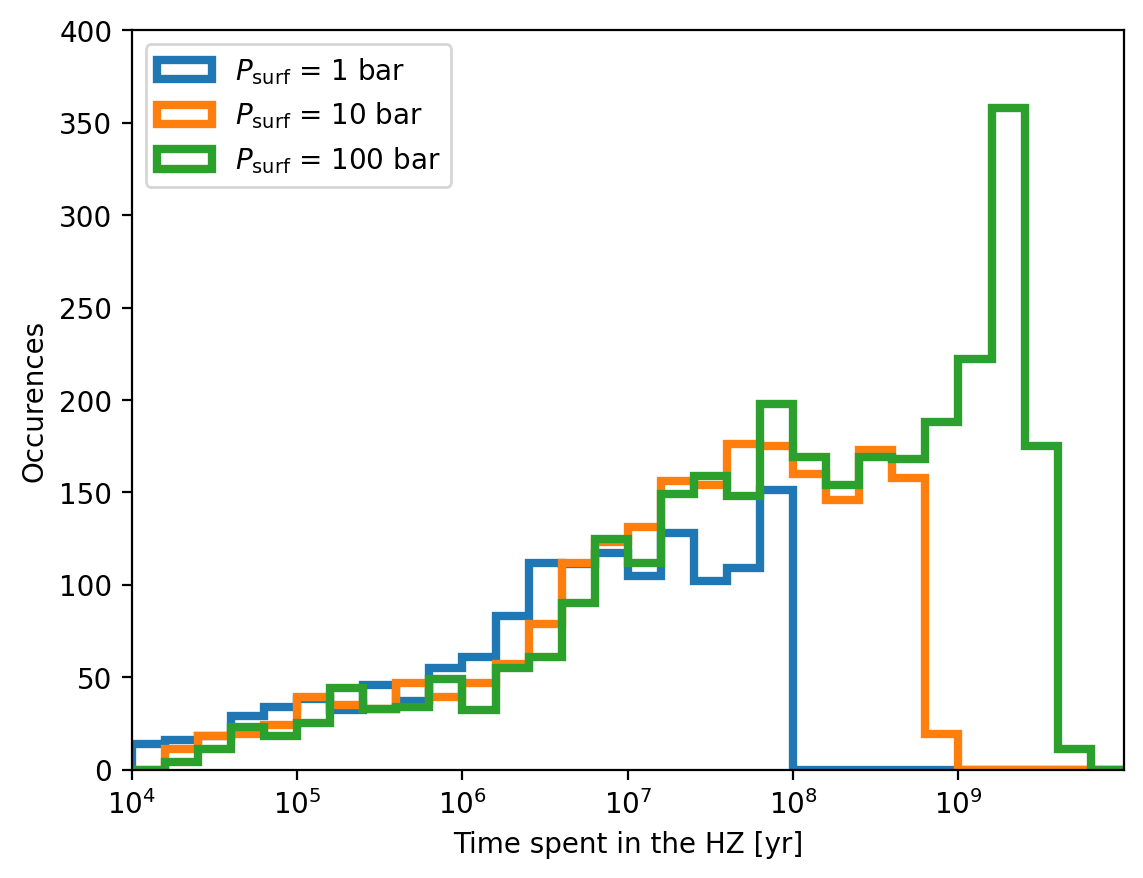

In [12]:
i_loop = 0

hist_min = 4 - 6
hist_max = 10 - 6

print(f'Habitability for an {loop_overs[i_loop]} atmosphere')
for i_p, P in enumerate(P0s):
    mask = time_habitable[i_loop, i_p, :] > 0

    #mask = np.logical_and(mask, switches[i_loop, i_p, :] == 2)

    print(f'for P0 = {P*1e-6:g} bar:', np.sum(mask), 'out of', len(mask), f'or {np.sum(mask)/len(mask)*100:.1f}% reach the HZ')
    min_time, max_time = time_habitable[i_loop, i_p, mask].min(), time_habitable[i_loop, i_p, :].max()
    print('min:', min_time, 'max:', max_time)
    print('argmin:', np.where(time_habitable[i_loop, i_p, :] == min_time)[0][0], 'argmax:', np.where(time_habitable[i_loop, i_p, :] == max_time)[0][0])
    plt.hist(np.log10(time_habitable[i_loop, i_p, mask]), bins=np.linspace(hist_min, hist_max, 31), label=r'$P_\mathrm{surf}$ = ' + f'{P*1e-6:g} bar', histtype='step', linewidth=3)

plt.xticks(np.arange(hist_min, hist_max, 1), [r'$10^{i}$'.format(i=i) for i in np.arange(hist_min, hist_max, 1)+6])
plt.xlim(hist_min, hist_max)
plt.ylim(0,400)

#.title(f'{i_param.replace('plus', '+').replace('to', '/')} = {loop_overs[i_loop]:.0e} atmosphere')
#plt.title(f'{loop_overs[i_loop][1:]} atmosphere')
plt.xlabel('Time spent in the HZ [yr]')
plt.ylabel('Occurences')

plt.legend()

if False:
    plt.title('')
    #set_white(plt.gca())
    increase_size(plt.gca(), linewidth=2, fontsize=15, legendloc='upper left')

    plt.tight_layout()

    #plt.ylabel('')
    #plt.gca().set_yticklabels([])

    plt.savefig(f'images/Paper1/TimeInHZ_CplusO={CplusOs[i_CplusO]:.0e}_CtoO={CtoOs[i_CtoO]:g}{adds[i_loop]}.pdf')#, transparent=True)

In [13]:
# get index with the maximum time spent in the HZ
max_index = np.argmax(time_habitable[i_loop, :, :], axis=-1)
print(max_index, time_habitable.shape)
for i, max_ind in enumerate(max_index):
    print(f'Maximum time spent in the HZ: {np.max(time_habitable[i_loop, i, max_ind])} yr for P0 = {P0s[i]*1e-6:.0f} bar')
    print(f'Index: {max_ind}, T_eff_init: {T_eff[max_ind, 0, 2]:.0f} K')
    # print the initial semi-major axis and eccentricity
    #print(f'Initial a_moon: {T_eff[max_ind, 0, 3]:.0f} cm, e_moon: {T_eff[max_ind, 0, 4]:.2f}')
    # print tminmax
    # print(t_minmax[i_loop, i, max_ind, :])

[6250 2135  241] (2, 3, 6945)
Maximum time spent in the HZ: 95.74556403273216 yr for P0 = 1 bar
Index: 6250, T_eff_init: 166 K
Maximum time spent in the HZ: 698.6403064842376 yr for P0 = 10 bar
Index: 2135, T_eff_init: 94 K
Maximum time spent in the HZ: 4340.684054855384 yr for P0 = 100 bar
Index: 241, T_eff_init: 56 K


In [14]:
# constants

# Galilean moons
name_moons = ['Io', 'Europa', 'Ganymede', 'Callisto']
a_moons = np.array([421800e5, 671100e5, 1070400e5, 1882700e5]) # cm
e_moons = np.array([0.0041, 0.0094, 0.0011, 0.0074])

R_J = 71492e5 # cm

4.837481178741948e-05 1.0
2.8286631037336568e-05 1.0
4.6375072299467236e-06 1.0


Text(0, 0.5, 'Eccentricity')

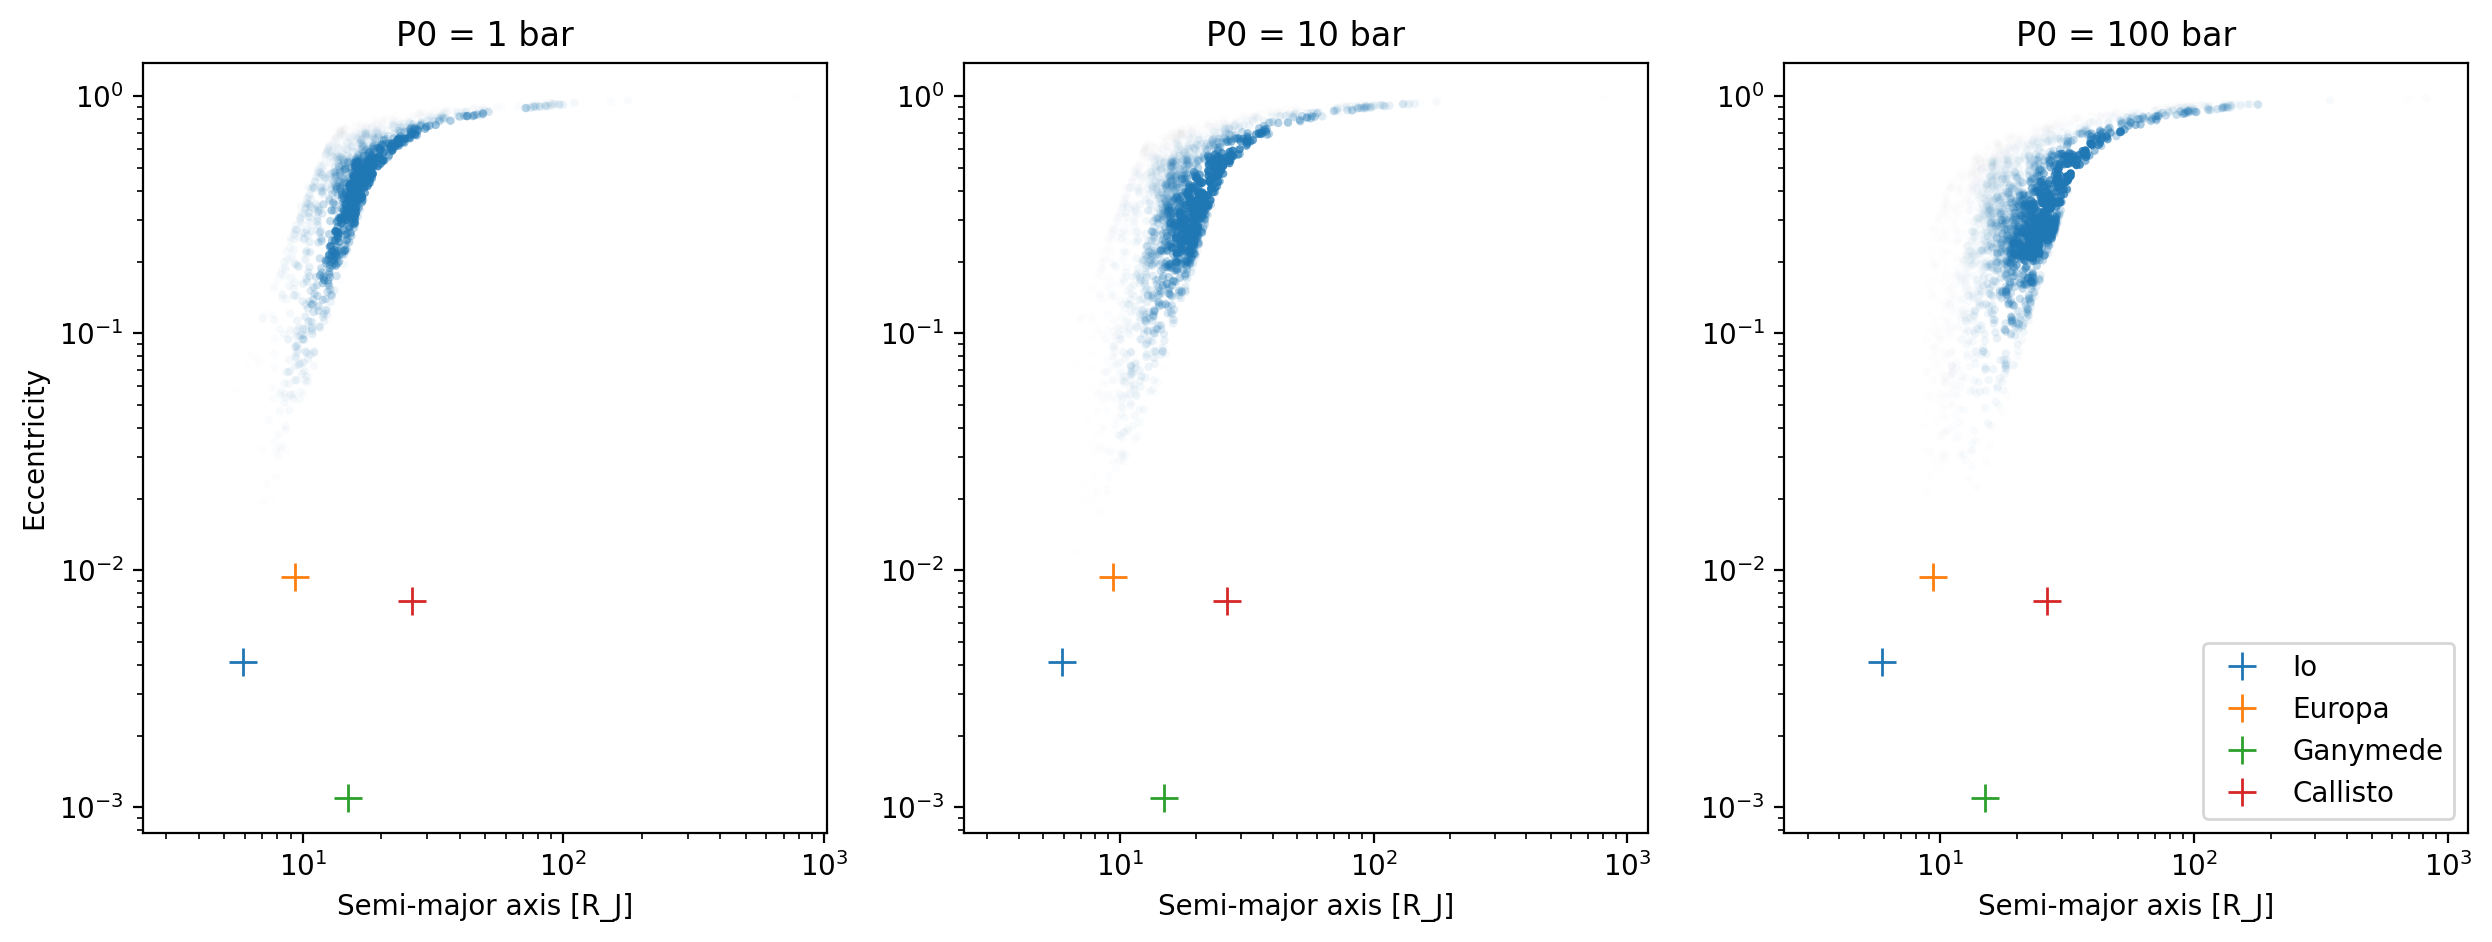

In [15]:
# track HZ back to inital semi-major axis

fig, ax = plt.subplots(1,3, figsize=(15,5))

habitable_mask = time_habitable[i_loop, :, :] > 0

for i_p, P in enumerate(P0s[::1]):
    habitable_mask_iP = habitable_mask[i_p,:]
    
    a_habitable = T_eff[habitable_mask_iP,0,3]
    e_habitable = T_eff[habitable_mask_iP,0,4]
    t_habitable_norm = time_habitable[i_loop, i_p, habitable_mask_iP]
    #t_habitable_norm = np.log10(t_habitable_norm)
    #t_habitable_norm = (t_habitable_norm - t_habitable_norm.min())/(t_habitable_norm.max() - t_habitable_norm.min())
    t_habitable_norm = t_habitable_norm/t_habitable_norm.max()
    print(t_habitable_norm.min(), t_habitable_norm.max())

    ax[i_p].scatter(a_habitable / R_J, e_habitable, marker='.', edgecolor='none', alpha=t_habitable_norm)#, label=f'P0 = {P*1e-6:.0f} bar', zorder=-i_p)

    for i_moon, (a_moon, e_moon) in enumerate(zip(a_moons, e_moons)):
        ax[i_p].plot(a_moon/R_J, e_moon, '+', label=name_moons[i_moon], ms=10)

    ax[i_p].set_xscale('log')
    ax[i_p].set_yscale('log')

    ax[i_p].set_title(f'P0 = {P*1e-6:.0f} bar')
    ax[i_p].set_xlabel('Semi-major axis [R_J]')

ax[-1].legend()
ax[0].set_ylabel('Eccentricity')

[1401 2131 2984]
4.837481178741948e-05 1.0
2.8286631037336568e-05 1.0
4.6375072299467236e-06 1.0


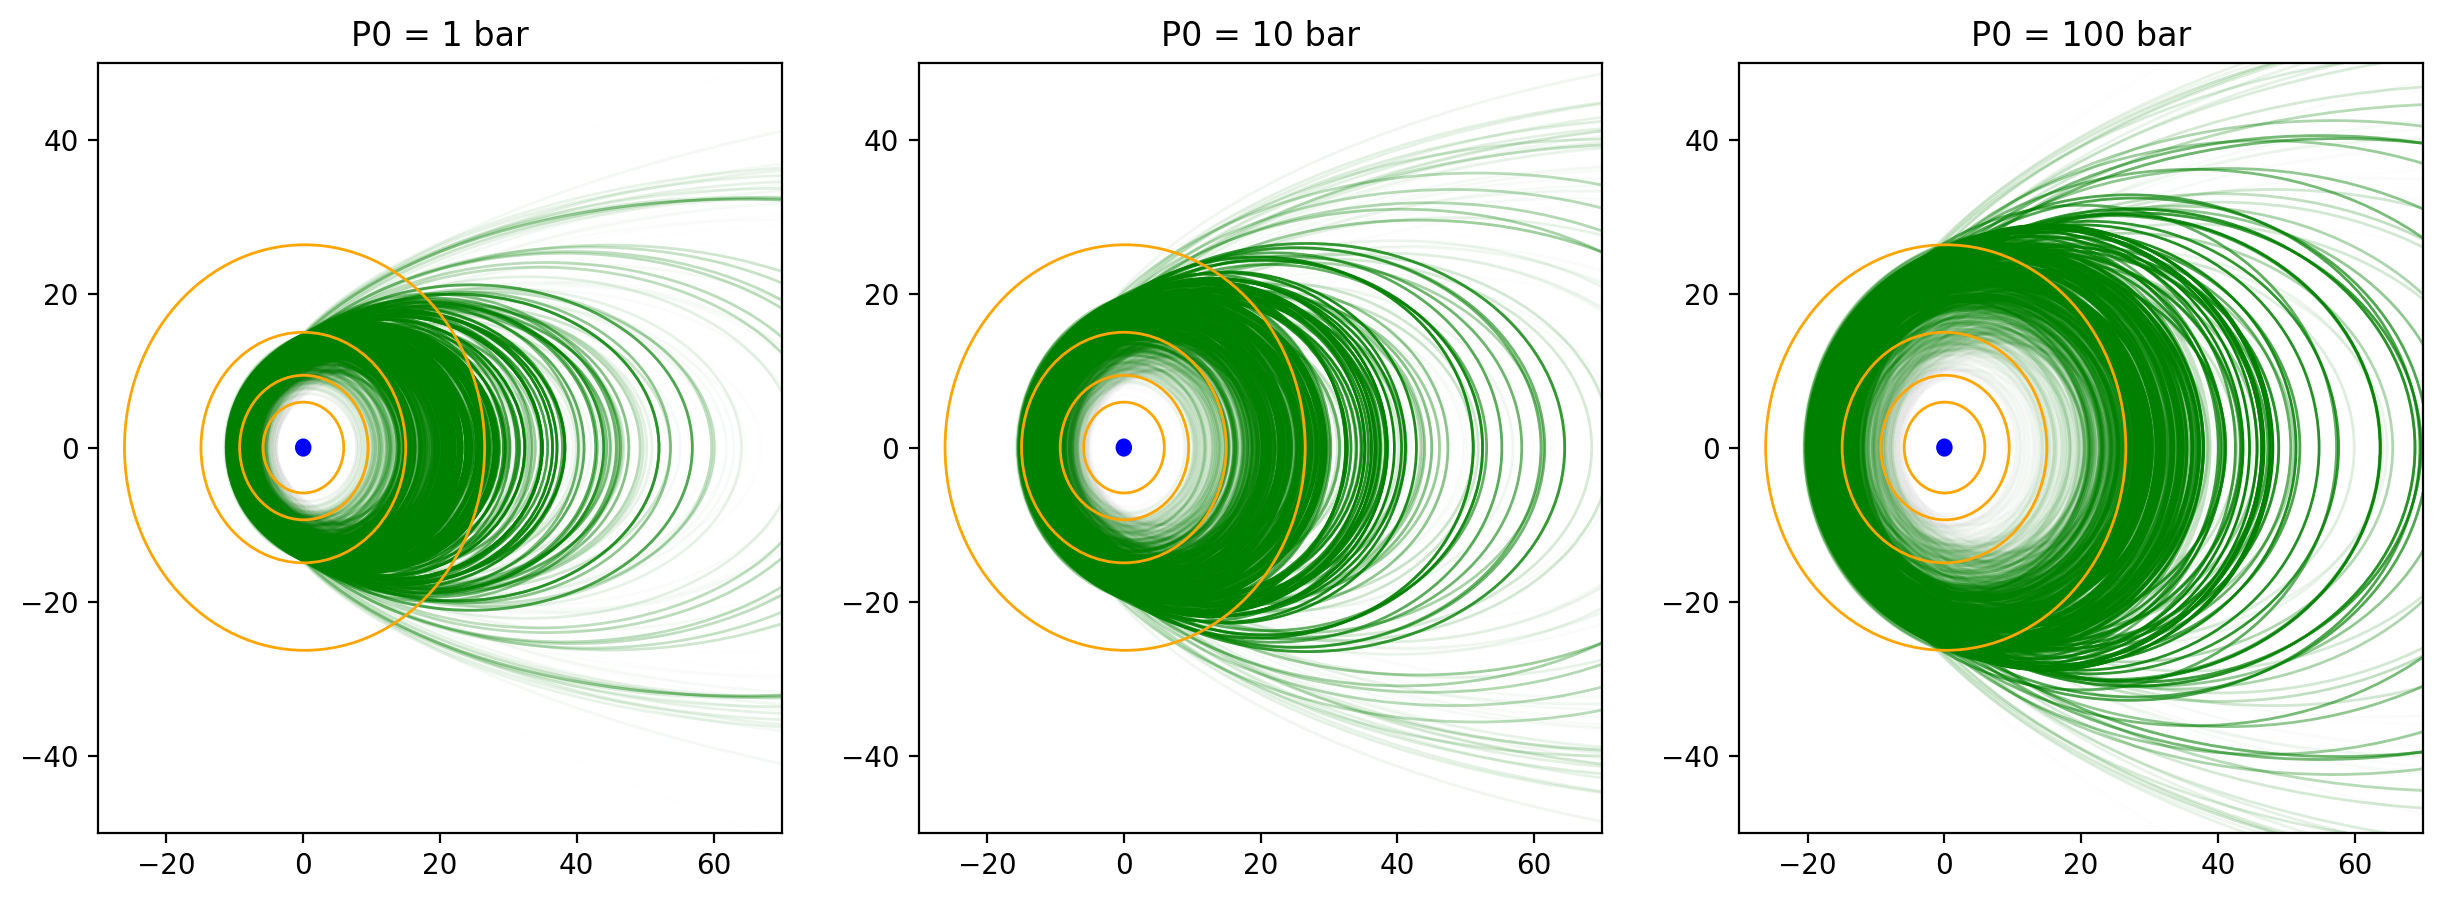

In [17]:
# plot actual orbits

fig, ax = plt.subplots(1,3, figsize=(15,5))

habitable_mask = time_habitable[i_loop, :, :] > 0
print(np.sum(habitable_mask, axis=-1))

i_time = 0
n_samples = 1000

for i_p, P in enumerate(P0s[::1]):
    habitable_mask_iP = habitable_mask[i_p,:]
    
    a_habitable = T_eff[habitable_mask_iP,i_time,3]
    e_habitable = T_eff[habitable_mask_iP,i_time,4]

    b_habitable = a_habitable * np.sqrt(1 - e_habitable**2)
    c_habitable = a_habitable * e_habitable

    t_habitable_norm = time_habitable[i_loop, i_p, habitable_mask_iP]
    #t_habitable_norm = np.log10(t_habitable_norm)
    #t_habitable_norm = (t_habitable_norm - t_habitable_norm.min())/(t_habitable_norm.max() - t_habitable_norm.min())
    t_habitable_norm = t_habitable_norm/t_habitable_norm.max()
    print(t_habitable_norm.min(), t_habitable_norm.max())


    for i_sample in range(n_samples):
        i_habitable = np.random.choice(len(a_habitable), size=1)[0]
        a_habitable_sample = a_habitable[i_habitable]
        e_habitable_sample = e_habitable[i_habitable]
        b_habitable_sample = b_habitable[i_habitable]
        c_habitable_sample = c_habitable[i_habitable]
        ax[i_p].add_patch(Ellipse((c_habitable_sample/R_J,0), width=2*a_habitable_sample/R_J, height=2*b_habitable_sample/R_J, fill=False, color='green', alpha=t_habitable_norm[i_habitable]))

    # add Jupiter and moons
    ax[i_p].add_patch(Ellipse((0,0), width=2, height=2, fill=True, color='blue'))
    for i_moon, (a_moon, e_moon) in enumerate(zip(a_moons, e_moons)):
        b_moon = a_moon * np.sqrt(1 - e_moon**2)
        c_moon = a_moon * e_moon
        ax[i_p].add_patch(Ellipse((c_moon/R_J,0), width=2*a_moon/R_J, height=2*b_moon/R_J, fill=False, color='orange'))

    max_a = 50
    dx = 20
    ax[i_p].set_xlim(-max_a+dx, max_a+dx)
    ax[i_p].set_ylim(-max_a, max_a)
    
    ax[i_p].set_title(f'P0 = {P*1e-6:.0f} bar')
    #ax[i_p].set_xlabel('[R_J]')

#ax[-1].legend()